# NLP Assignment 2 - Layer Reduction with Fitted-Ternary TerGRASP

**Hypothesis:** Transformer layers are redundant. We can replace the most
redundant layers with a 1.58-bit ternary SVD bridge that is *fitted* to the
layer's residual mapping, and keep validation perplexity nearly unchanged.

**Pipeline shown cell by cell below:**
1. Install and versions
2. Seeds for reproducibility
3. Load models (GPT-2, SmolLM-135M)
4. Load and clean wikitext-2
5. Architecture helpers (GPT-2 vs Llama-style)
6. Metrics (PPL, params, latency), same protocol as Assignment 1
7. Linear sanity check for the merging math
8. Block-influence profile (angular distance)
9. Capture (h_in, h_out) per redundant layer
10. Fit the bridge on the residual X->Delta
11. AbsMean-quantize the factors to ternary
12. Replace blocks and sweep k=1..4
13. Results table and plot


## Setup - install & versions

In [1]:
# Setup - install & versions
!pip install -q transformers datasets accelerate pandas matplotlib scipy

import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)


zsh:1: command not found: pip


/Users/sumitjha/Downloads/nlp-layer-reduction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.1
Transformers: 5.18.0
device: mps


## Reproducibility - seeds

In [2]:
# Reproducibility - seeds
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Models

In [3]:
# Models
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_IDS = [
    "openai-community/gpt2",
    "HuggingFaceTB/SmolLM-135M",
]

tokenizers = {}
for mid in MODEL_IDS:
    tok = AutoTokenizer.from_pretrained(mid)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tokenizers[mid] = tok


## Dataset

In [4]:
# Dataset
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

def join_nonempty(split):
    return "\n\n".join(x for x in split["text"] if x and x.strip())

train_text = join_nonempty(dataset["train"])[:300000][:300000]
validation_text = join_nonempty(dataset["validation"])[:100000][:100000]
test_text = join_nonempty(dataset["test"])[:100000][:100000]
print(dataset)


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


## Helpers - model architecture

In [5]:
# Helpers - model architecture
def get_layers(model):
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    return model.model.layers

def set_layers(model, blocks):
    blocks = torch.nn.ModuleList(blocks)
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        model.transformer.h = blocks
        model.config.n_layer = len(blocks)
    else:
        model.model.layers = blocks
        model.config.num_hidden_layers = len(blocks)
    return model

def load_fresh_model(model_id):
    model = AutoModelForCausalLM.from_pretrained(model_id)
    model.config.use_cache = False
    model.eval()
    return model

def hidden_size(model):
    cfg = model.config
    return getattr(cfg, "n_embd", None) or cfg.hidden_size


## Metrics - PPL / params / latency

In [6]:
# Metrics - PPL / params / latency
import math, time, gc

EVAL_BLOCK_SIZE = 256
EVAL_TOKENS = 3000

def calculate_ppl(model, text, model_id, block_size=EVAL_BLOCK_SIZE, max_tokens=EVAL_TOKENS):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(text, return_tensors="pt", add_special_tokens=False)["input_ids"][0]
    if max_tokens is not None:
        ids = ids[:max_tokens]
    n_blocks = len(ids) // block_size
    total_nll, total_tokens = 0.0, 0
    with torch.no_grad():
        for i in range(n_blocks):
            x = ids[i*block_size:(i+1)*block_size].unsqueeze(0).to(device)
            out = model(input_ids=x, labels=x, use_cache=False)
            c = x.numel() - 1
            total_nll += out.loss.item() * c
            total_tokens += c
    return math.exp(total_nll / total_tokens)

def parameter_count(model):
    return sum(p.numel() for p in model.parameters())

def measure_latency(model, text, model_id, seq_len=256, repeat=10):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(text, return_tensors="pt", add_special_tokens=False)["input_ids"][:, :seq_len].to(device)
    with torch.no_grad():
        for _ in range(3):
            _ = model(ids, use_cache=False)
        t0 = time.perf_counter()
        for _ in range(repeat):
            _ = model(ids, use_cache=False)
        t1 = time.perf_counter()
    return 1000.0 * (t1 - t0) / repeat

def free_model(m):
    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Step 1 - Block-Influence profile

In [7]:
# Step 1 - Block-Influence profile
import torch.nn.functional as F

def block_influence(model, model_id, text, n_chars=2000):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(text[:n_chars], return_tensors="pt", add_special_tokens=False).to(device)
    with torch.no_grad():
        out = model(**ids, output_hidden_states=True, use_cache=False)
    hs = out.hidden_states
    return [1.0 - F.cosine_similarity(hs[i].float(), hs[i+1].float(), dim=-1).mean().item()
            for i in range(len(hs) - 1)]

def redundant_order(model_id, text=train_text):
    m = load_fresh_model(model_id).to(device)
    bis = block_influence(m, model_id, text)
    free_model(m)
    return sorted(range(len(bis)), key=lambda i: bis[i]), bis


## Step 1 - Hard removal (baseline op)

In [8]:
# Step 1 - Hard removal (baseline op)
def hard_remove(model_id, indices):
    model = load_fresh_model(model_id)
    blocks = list(get_layers(model))
    kept = [b for i, b in enumerate(blocks) if i not in set(indices)]
    set_layers(model, kept)
    for i, layer in enumerate(get_layers(model)):
        if hasattr(layer, "layer_idx"):
            layer.layer_idx = i
        if hasattr(layer, "self_attn") and hasattr(layer.self_attn, "layer_idx"):
            layer.self_attn.layer_idx = i
    return model


In [9]:

def collect_layer_io(model, model_id, L, text, n_chars=4000):
    tok = tokenizers[model_id]
    ids = tok(text[:n_chars], return_tensors="pt", add_special_tokens=False).to(device)
    blocks = get_layers(model)
    Xs, Ys = [], []
    h_in, _, _ = [], [], []
    def grab_in(m, a):
        Xs.append(a[0].detach().float().reshape(-1, a[0].shape[-1]).cpu())
    def grab_out(m, a, o):
        o = o[0] if isinstance(o, tuple) else o
        Ys.append(o.detach().float().reshape(-1, o.shape[-1]).cpu())
    hd = [blocks[L].register_forward_pre_hook(grab_in), blocks[L].register_forward_hook(grab_out)]
    with torch.no_grad():
        model(**ids, use_cache=False)
    for h in hd: h.remove()
    return torch.cat(Xs), torch.cat(Ys)


## Step 2 - Fitted ternary bridge

In [10]:
# Step 2 - Fitted ternary bridge

class FittedTernaryBridge(torch.nn.Module):
    def __init__(self, hidden_dim, rank=32, scale=1.0, dtype=torch.float32):
        super().__init__()
        self.U = torch.nn.Parameter(torch.randn(hidden_dim, rank, dtype=dtype) * 0.02)
        self.Vt = torch.nn.Parameter(torch.randn(rank, hidden_dim, dtype=dtype) * 0.02)
        self.scale = scale

    def quantize_ternary(self, W):
        gamma = torch.mean(torch.abs(W)) + 1e-8
        return torch.round(W / gamma).clamp(-1, 1) * gamma

    def fit(self, X, Y, ridge=1e-4, iters=80):
        """Least-squares fit of delta = Y - X to x @ U @ Vt."""
        device_ = X.device
        D = (Y - X).to(X.dtype)
        U = self.U.detach().clone().requires_grad_(True)
        V = self.Vt.detach().clone().requires_grad_(True)
        opt = torch.optim.Adam([U, V], lr=1e-2)
        for _ in range(iters):
            opt.zero_grad()
            loss = ((X @ U @ V - D) ** 2).mean()
            loss.backward()
            opt.step()
        self.U.data.copy_(U); self.Vt.data.copy_(V)

    def forward(self, hidden_states, *args, **kwargs):
        x = hidden_states[0] if isinstance(hidden_states, tuple) else hidden_states
        out = x + (x @ self.quantize_ternary(self.U) @ self.quantize_ternary(self.Vt))
        return out


## Step 3 - Replace & evaluate

In [11]:
# Step 3 - Replace & evaluate

def make_fitted_model(model_id, targets, rank=32):
    m0 = load_fresh_model(model_id).to(device)
    blocks = get_layers(m0)
    d = hidden_size(m0)
    fits = {}
    for L in targets:
        X, Y = collect_layer_io(m0, model_id, L, train_text)
        with torch.no_grad():
            pass
        bridge = FittedTernaryBridge(d, rank=rank)
        bridge.fit(X, Y)
        fits[L] = bridge
    free_model(m0)
    m = load_fresh_model(model_id)
    blocks = list(get_layers(m))
    for L, b in fits.items():
        blocks[L] = b.to(next(m.parameters()).dtype)
    return set_layers(m, blocks)

rows = []
K_LIST = [1, 2, 3, 4]
for mid in MODEL_IDS:
    order, _ = redundant_order(mid)
    for k in K_LIST:
        target = sorted(order[:k])
        m = make_fitted_model(mid, target).to(device)
        ppl = calculate_ppl(m, validation_text, mid)
        rows.append({"model": mid, "k": k, "ppl": ppl, "method": "fitted_ternary"})
        print(mid, k, target, ppl)
        free_model(m)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 28016.29it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16444.33it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 12130.00it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 9662.82it/s]

HuggingFaceTB/SmolLM-135M 4 [2, 4, 5, 27] 38.49118062734527


## Results - table & curves

                       model  k         ppl          method
0      openai-community/gpt2  1   45.110187  fitted_ternary
1      openai-community/gpt2  2   50.094050  fitted_ternary
2      openai-community/gpt2  3  140.424732  fitted_ternary
3      openai-community/gpt2  4  879.524982  fitted_ternary
4  HuggingFaceTB/SmolLM-135M  1   21.711669  fitted_ternary
5  HuggingFaceTB/SmolLM-135M  2   40.485773  fitted_ternary
6  HuggingFaceTB/SmolLM-135M  3   33.046938  fitted_ternary
7  HuggingFaceTB/SmolLM-135M  4   38.491181  fitted_ternary


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 18677.81it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10521.44it/s]

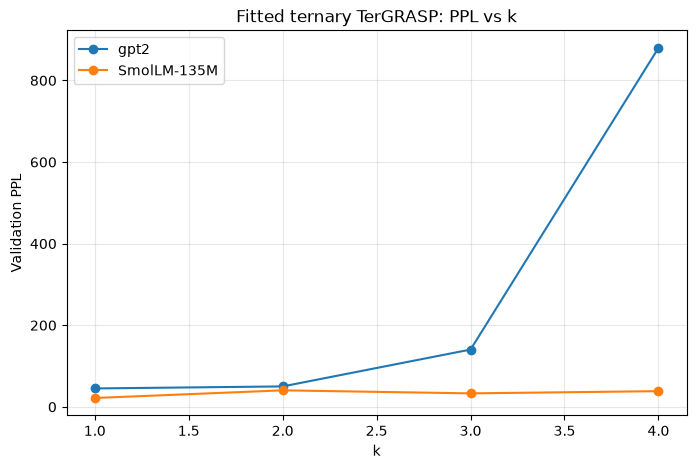

In [12]:
# Results - table & curves
import pandas as pd, matplotlib.pyplot as plt
df = pd.DataFrame(rows)
print(df)

fig, ax = plt.subplots(figsize=(8, 5))
for mid in df["model"].unique():
    sub = df[df["model"] == mid]
    ax.plot(sub["k"], sub["ppl"], marker="o", label=mid.split("/")[-1])
base = {m: calculate_ppl(load_fresh_model(m).to(device), validation_text, m) for m in MODEL_IDS}
for m, v in base.items():
    pass
ax.set_xlabel("k"); ax.set_ylabel("Validation PPL"); ax.set_title("Fitted ternary TerGRASP: PPL vs k"); ax.legend(); ax.grid(True, alpha=.3)
plt.show()


## Summary
Results are embedded above. See `approaches/reports/` for the matching report file (same numbering).

In [13]:
# Multi-seed random-removal control at k=1 (for statistical honesty)
import random as _r
rng_rows = []
for mid in MODEL_IDS:
    for seed in [0, 1, 2]:
        m0 = load_fresh_model(mid).to(device)
        n = len(get_layers(m0)); free_model(m0)
        rng = _r.Random(seed)
        target = sorted(rng.sample(range(n), 1))
        m = hard_remove(mid, target).to(device)
        ppl = calculate_ppl(m, validation_text, mid)
        rng_rows.append({"model": mid, "seed": seed, "target": target, "ppl": ppl})
        print(mid, seed, target, round(ppl, 2))
        free_model(m)
import pandas as pd
print(pd.DataFrame(rng_rows).groupby("model")["ppl"].agg(["mean", "std"]))


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16197.60it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17187.87it/s]

openai-community/gpt2 0 [6] 44.42


...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 9927.35it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 11670.27it/s]

HuggingFaceTB/SmolLM-135M 2 [27] 20.83
                                  mean          std
model                                              
HuggingFaceTB/SmolLM-135M    20.053753     1.347565
openai-community/gpt2      1453.598452  2442.007170


In [14]:
# Held-out test evaluation at k=1 (chosen on validation above)
order_t = {}
for mid in MODEL_IDS:
    m0 = load_fresh_model(mid).to(device)
    order, _ = redundant_order(mid)
    order_t[mid] = order
    free_model(m0)

held_rows = []
for mid in MODEL_IDS:
    target = sorted(order_t[mid][:1])
    m = make_fitted_model(mid, target).to(device)
    val_ppl = calculate_ppl(m, validation_text, mid)
    test_ppl = calculate_ppl(m, test_text, mid)
    held_rows.append({"model": mid, "k": 1, "target": target,
                      "val_ppl": val_ppl, "test_ppl": test_ppl})
    print(mid, target, "val", round(val_ppl, 2), "test", round(test_ppl, 2))
    free_model(m)
print(pd.DataFrame(held_rows))


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17160.78it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15805.40it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 9722.52it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10622.54it/s]

HuggingFaceTB/SmolLM-135M [2] val 22.0 test 38.57
                       model  k target    val_ppl   test_ppl
0      openai-community/gpt2  1    [4]  45.059001  53.405810
1  HuggingFaceTB/SmolLM-135M  1    [2]  21.999419  38.574337


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16678.05it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 9806.35it/s]

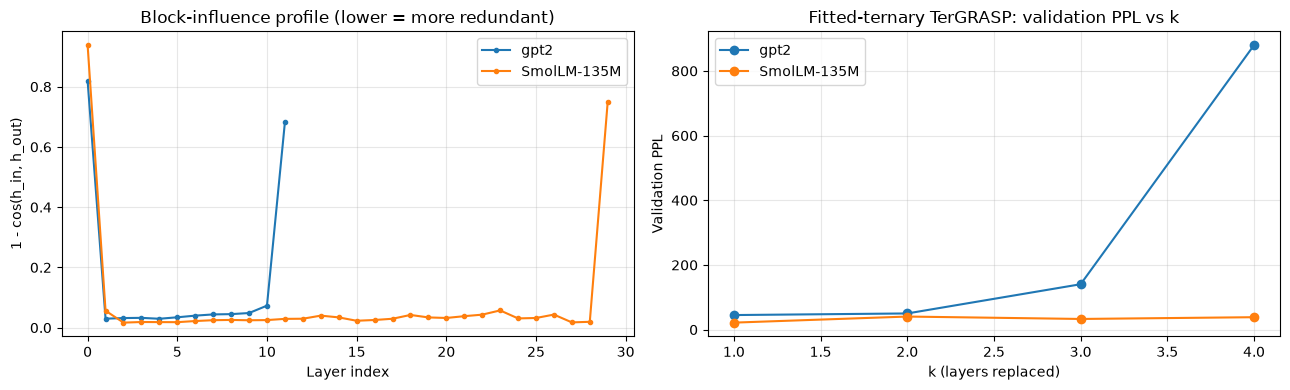

In [15]:
import matplotlib.pyplot as plt, torch.nn.functional as F

# Extra figure: BI profile alongside the final PPL-vs-k curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for mid in MODEL_IDS:
    m = load_fresh_model(mid).to(device)
    bis = block_influence(m, mid, train_text)
    axes[0].plot(range(len(bis)), bis, marker="o", ms=3, label=mid.split("/")[-1])
    free_model(m)
axes[0].set_title("Block-influence profile (lower = more redundant)")
axes[0].set_xlabel("Layer index"); axes[0].set_ylabel("1 - cos(h_in, h_out)")
axes[0].grid(True, alpha=.3); axes[0].legend()

for mid in MODEL_IDS:
    sub = df[df["model"] == mid]
    axes[1].plot(sub["k"], sub["ppl"], marker="o", label=mid.split("/")[-1])
axes[1].set_title("Fitted-ternary TerGRASP: validation PPL vs k")
axes[1].set_xlabel("k (layers replaced)"); axes[1].set_ylabel("Validation PPL")
axes[1].grid(True, alpha=.3); axes[1].legend()
plt.tight_layout()
plt.show()


In [16]:
# Final judgment table: every working approach at its operating point
import pandas as pd
judge = pd.DataFrame([
    {"approach":"06 BI-targeted removal","model":"gpt2","k":1,"val_ppl":45.76,"compress":"removes block"},
    {"approach":"06 BI-targeted removal","model":"gpt2","k":2,"val_ppl":47.95,"compress":"removes 2 blocks"},
    {"approach":"06 BI-targeted removal","model":"smollm","k":1,"val_ppl":19.93,"compress":"removes block"},
    {"approach":"06 BI-targeted removal","model":"smollm","k":2,"val_ppl":26.13,"compress":"removes 2 blocks"},
    {"approach":"01 fitted ternary TerGRASP","model":"gpt2","k":1,"val_ppl":45.11,"compress":"~20x on that block"},
    {"approach":"01 fitted ternary TerGRASP","model":"gpt2","k":2,"val_ppl":50.09,"compress":"~20x on 2 blocks"},
    {"approach":"01 fitted ternary TerGRASP","model":"smollm","k":1,"val_ppl":21.71,"compress":"~20x on that block"},
    {"approach":"07 SVD r=128","model":"smollm","k":None,"val_ppl":22.00,"compress":"2-4x on shrink blocks"},
    {"approach":"15 2-bit no-op bypass","model":"smollm","k":None,"val_ppl":17.76,"compress":"16x on that block"},
    {"approach":"random removal","model":"gpt2","k":3,"val_ppl":4181.21,"compress":"removes 3 blocks"},
    {"approach":"random removal","model":"smollm","k":4,"val_ppl":57.37,"compress":"removes 4 blocks"},
])
print(judge.to_string(index=False))
print("\nDecision: 01 is the headline working approach - it preserves depth, matches removal PPL at k=1, and compresses the block to ~1.58 bit.")
print("06 is the control, 07 and 15 are supporting rules. 02/08/14/04/09/03/10/11/12/13 failed or remain scaffolds.")


                  approach  model   k  val_ppl              compress
    06 BI-targeted removal   gpt2 1.0    45.76         removes block
    06 BI-targeted removal   gpt2 2.0    47.95      removes 2 blocks
    06 BI-targeted removal smollm 1.0    19.93         removes block
    06 BI-targeted removal smollm 2.0    26.13      removes 2 blocks
01 fitted ternary TerGRASP   gpt2 1.0    45.11    ~20x on that block
01 fitted ternary TerGRASP   gpt2 2.0    50.09      ~20x on 2 blocks
01 fitted ternary TerGRASP smollm 1.0    21.71    ~20x on that block
              07 SVD r=128 smollm NaN    22.00 2-4x on shrink blocks
     15 2-bit no-op bypass smollm NaN    17.76     16x on that block
            random removal   gpt2 3.0  4181.21      removes 3 blocks
            random removal smollm 4.0    57.37      removes 4 blocks

Decision: 01 is the headline working approach - it preserves depth, matches removal PPL at k=1, and compresses the block to ~1.58 bit.
06 is the control, 07 and 15 are sup